# QualityPhys - Camera Remote Vital Signs Estimator (CRVSE) Project

## Notebook P3-23: HR PhaseNet - native loss vs SNR loss

### What this notebook does
Introduces PhaseNet (Zhao et al., CVPR 2026 - Physics-Grounded Harmonic Attention System) into the CRVSE pipeline and, in one notebook, trains it twice on one fixed subject-wise split: once with PhaseNet's OWN native loss and once with the CRVSE SNR loss. PhaseNet is a lightweight, physics-grounded model - its pulse dynamics are derived from the Navier-Stokes equations of hemodynamics, which reduce to a causal convolution and justify a Temporal Convolutional Network. It pairs a MobileNet-style spatiotemporal encoder, a zero-FLOPs temporal-interlacing module, a spatial-attention head, a gated TCN, and a latent-reconstruction regulariser. It is pure PyTorch (NO mamba-ssm, NO LLM, NO diffusion) and consumes our 72x72 clips directly - it is spatially adaptive, so no upsampling is needed (unlike PhysFormer / RhythmFormer).

### The two configs 
- **native**: PhaseNet's own recipe, read from its trainer - neg-Pearson + 0.2 * the model's latent-reconstruction loss (its spectral term ships at weight 0 = off). Adam, lr 1e-4, no scheduler.
- **snr**: the CRVSE v2 recipe - neg-Pearson + LAMBDA_SNR * snr_loss (in-band SNR at the reference fundamental + first harmonic, per-sample fps, invalid-HR clips masked), each clip cardiac_sqi-weighted - plus the same 0.2 * recon regulariser, so only the pulse-supervision term changes between the two runs.

### Why
PhaseNet is the stablest, lowest-dependency (a TCN, no fragile deps) and is built for motion + illumination robustness. Running native-vs-SNR in one notebook answers whether the CRVSE SNR loss helps it - the loss has proven architecture-dependent (it helped PhysNet, PhysFormer and RhythmFormer, but regressed RhythmMamba). Both runs are read against PhysNet v2 (shared 5.22, MCD 6.84; NB_P3_18).

### Rules
- One fixed subject-wise split (seed 42). Train MCD + DLCN + UBFC-rPPG; PhysDrive is evaluation-only (zero-shot). Both configs use the identical split and are checkpointed on the shared MCD+DLCN+UBFC MAE.
- PhaseNet from the official repo (Alex036225/PhaseNet), default gated-TCN temporal module as shipped (feature_dim 128, latent 32, hidden 128, 4 TCN layers; a phase-aware harmonic-attention module also exists in the repo). No frames are rendered.

## 1. Imports & Config (+ clone PhaseNet, install thop)

In [1]:
import os, sys, time, random, gc, glob, importlib
from pathlib import Path
from collections import Counter
import numpy as np
import pandas as pd
import h5py
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.amp import autocast, GradScaler

# Clone PhaseNet (pure-PyTorch TCN - NO mamba-ssm) and expose it on the path.
if not os.path.exists('PhaseNet'):
    os.system('git clone --depth 1 https://github.com/Alex036225/PhaseNet')
sys.path.append('PhaseNet')
for d in glob.glob('PhaseNet/**/', recursive=True):
    sys.path.append(d)
os.system('pip install thop einops -q')   # PhaseNet.py imports thop at module load

# locate the four Phase-3 datasets across Kaggle inputs (PhysDrive is held-out eval)
WANT = ['mcd_phase3.h5', 'dlcn_phase3.h5', 'ubfc_rppg_phase3.h5', 'physdrive_phase3.h5']
H5_PATHS = []
for name in WANT:
    hits = list(Path('/kaggle/input').rglob(name))
    if hits:
        H5_PATHS.append(hits[0])
print('datasets found:', [p.name for p in H5_PATHS])

CONFIGS = ['native', 'snr']
TRAIN_SET = {'MCD', 'DLCN', 'UBFC-rPPG'} # PhysDrive excluded from training (held-out)
SHARED_DATASETS = {'MCD', 'DLCN', 'UBFC-rPPG'} # checkpoint metric
REF_PHYSNET_V2 = {'MCD': 6.84, 'DLCN': 3.08, 'UBFC-rPPG': 3.13, 'shared': 5.22}   # NB_P3_18 best (the model to beat)

CLIP_LEN = 160
IMG_SIZE = 72
BATCH_SIZE = 4 # PhaseNet uses InstanceNorm (batch-independent); raise to 8 if headroom, drop to 2 if OOM
CLIPS_PER_REC = 2
NUM_WORKERS = 2
VAL_FRAC = 0.2
SEED = 42
AUG_PROB = 0.5
SPEED_MIN, SPEED_MAX = 0.7, 2.0
SQI_FLOOR = 0.05

# PhaseNet recipe (from the official PhaseNetTrainer + config): Adam, fixed lr, NO scheduler; native loss = neg-Pearson + BETA_RECON*recon
LR = 1e-4
EPOCHS = 20 # PhaseNet paper used 10 on tiny UBFC; extended for our larger + noisier corpus
BETA_RECON = 0.2 # PhaseNet's latent-reconstruction weight (both configs)
LAMBDA_SNR = 0.05 # CRVSE SNR-loss weight (snr config only)
HR_LOW, HR_HIGH = 0.66, 3.0
PN_FEATURE_DIM, PN_LATENT_DIM, PN_HIDDEN_DIM, PN_TCN_LAYERS = 128, 32, 128, 4

device = 'cuda' if torch.cuda.is_available() else 'cpu'
torch.manual_seed(SEED); np.random.seed(SEED); random.seed(SEED)
torch.backends.cudnn.benchmark = True
print('device:', device, '| configs:', CONFIGS, '| train on:', sorted(TRAIN_SET), '| PhysDrive = held-out eval')

Cloning into 'PhaseNet'...


datasets found: ['mcd_phase3.h5', 'dlcn_phase3.h5', 'ubfc_rppg_phase3.h5', 'physdrive_phase3.h5']
device: cuda | configs: ['native', 'snr'] | train on: ['DLCN', 'MCD', 'UBFC-rPPG'] | PhysDrive = held-out eval


## 2. Data Loader - index, one fixed subject-split

In [2]:
def build_index(h5_paths, sqi_floor=SQI_FLOOR, clip_len=CLIP_LEN):
    index = []
    for path in h5_paths:
        with h5py.File(path, 'r') as f:
            for name in f.keys():
                a = f[name].attrs
                if not bool(a.get('usable', True)):
                    continue
                if float(a.get('cardiac_sqi', 0.0)) < sqi_floor:
                    continue
                n = int(a['n_frames'])
                if n < clip_len:
                    continue
                index.append(dict(file=str(path), group=name, dataset=str(a.get('dataset', Path(path).stem)),
                                  subject=str(a.get('subject_id', name)), n_frames=n,
                                  fps=float(a.get('fps', 30.0)), sqi=float(a.get('cardiac_sqi', 0.0))))
    return index


def subject_split(index, val_frac=VAL_FRAC, seed=SEED):
    subjects = sorted({r['dataset'] + '/' + r['subject'] for r in index})
    rng = random.Random(seed); rng.shuffle(subjects)
    n_val = max(1, int(round(len(subjects) * val_frac)))
    val_subj = set(subjects[:n_val])
    tr = [r for r in index if (r['dataset'] + '/' + r['subject']) not in val_subj]
    va = [r for r in index if (r['dataset'] + '/' + r['subject']) in val_subj]
    return tr, va, val_subj


def compute_hr(bvp, fps, low=HR_LOW, high=HR_HIGH):
    x = np.asarray(bvp, dtype=np.float64); x = x - x.mean()
    if x.size < 16 or not np.all(np.isfinite(x)) or np.std(x) < 1e-9:
        return np.nan
    p = np.abs(np.fft.rfft(x * np.hanning(x.size))) ** 2
    fr = np.fft.rfftfreq(x.size, 1.0 / fps)
    b = (fr >= low) & (fr <= high)
    if not b.any() or p[b].sum() <= 0:
        return np.nan
    return float(fr[b][int(np.argmax(p[b]))] * 60.0)


class RPPGClipDataset(Dataset):
    def __init__(self, index, clip_len=CLIP_LEN, augment=False, clips_per_rec=1,
                 aug_prob=AUG_PROB, speed_range=(SPEED_MIN, SPEED_MAX), seed=SEED):
        self.index = index; self.clip_len = clip_len; self.augment = augment
        self.clips_per_rec = clips_per_rec; self.aug_prob = aug_prob; self.speed_range = speed_range
        self._files = {}; self._rng = np.random.default_rng(seed)

    def _h5(self, path):
        h = self._files.get(path)
        if h is None:
            h = h5py.File(path, 'r'); self._files[path] = h
        return h

    def __len__(self):
        return len(self.index) * self.clips_per_rec

    def __getitem__(self, i):
        rec = self.index[i % len(self.index)]; g = self._h5(rec['file'])[rec['group']]
        n, T = rec['n_frames'], self.clip_len
        if self.augment and self._rng.random() < self.aug_prob:
            src_len = int(round(T * float(self._rng.uniform(*self.speed_range))))
            src_len = max(T, min(src_len, n))
        else:
            src_len = T
        max_start = n - src_len
        start = int(self._rng.integers(0, max_start + 1)) if (self.augment and max_start > 0) else max_start // 2
        frames_src = g['frames'][start:start + src_len].astype(np.float32)
        bvp_src = g['bvp'][start:start + src_len].astype(np.float32)
        pos = np.linspace(0, src_len - 1, T)
        frames = frames_src[np.rint(pos).astype(int)]
        bvp = np.interp(pos, np.arange(src_len), bvp_src)
        hr_bpm = compute_hr(bvp, rec['fps'])
        if self.augment and self._rng.random() < 0.5:
            frames = frames[:, :, ::-1, :]
        m = frames.mean(axis=(0, 1, 2), keepdims=True); sd = frames.std(axis=(0, 1, 2), keepdims=True) + 1e-6
        frames = np.ascontiguousarray((frames - m) / sd)
        frames = torch.from_numpy(frames).permute(3, 0, 1, 2).float()
        bvp = (bvp - bvp.mean()) / (bvp.std() + 1e-6)
        bvp = torch.from_numpy(bvp.astype(np.float32))
        return dict(frames=frames, bvp=bvp,
                    hr=torch.tensor(hr_bpm if np.isfinite(hr_bpm) else 0.0, dtype=torch.float32),
                    sqi=torch.tensor(rec['sqi'], dtype=torch.float32),
                    fps=torch.tensor(rec['fps'], dtype=torch.float32),
                    dataset=rec['dataset'])


def worker_init_fn(worker_id):
    info = torch.utils.data.get_worker_info(); ds = info.dataset
    ds._files = {}; ds._rng = np.random.default_rng(SEED + 1000 * (worker_id + 1) + int(info.seed % 100000))


def make_loader(index, augment, clips_per_rec=1):
    ds = RPPGClipDataset(index, augment=augment, clips_per_rec=clips_per_rec)
    return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=augment, num_workers=NUM_WORKERS,
                      worker_init_fn=worker_init_fn, pin_memory=True, drop_last=augment,
                      persistent_workers=(NUM_WORKERS > 0))


index = build_index(H5_PATHS)
train_all, val_idx, val_subj = subject_split(index)   # ONE fixed split, shared by both configs
train_idx = [r for r in train_all if r['dataset'] in TRAIN_SET]
print('usable:', len(index), 'by dataset:', dict(Counter(r['dataset'] for r in index)))
print('val (FIXED):', len(val_idx), 'by dataset:', dict(Counter(r['dataset'] for r in val_idx)))
print('train recs:', len(train_idx), 'by dataset:', dict(Counter(r['dataset'] for r in train_idx)))

usable: 2276 by dataset: {'MCD': 1191, 'DLCN': 777, 'UBFC-rPPG': 42, 'PhysDrive': 266}
val (FIXED): 475 by dataset: {'MCD': 232, 'DLCN': 168, 'UBFC-rPPG': 7, 'PhysDrive': 68}
train recs: 1603 by dataset: {'MCD': 959, 'DLCN': 609, 'UBFC-rPPG': 35}


## 3. Model - PhaseNet (official repo, no mamba-ssm)

In [3]:
# Import PhaseNet (needs thop; pure PyTorch otherwise).
PhaseNetClass = None
for modname in ['neural_methods.model.PhaseNet.PhaseNet', 'model.PhaseNet.PhaseNet', 'PhaseNet.PhaseNet', 'PhaseNet']:
    try:
        m = importlib.import_module(modname)
        PhaseNetClass = getattr(m, 'PhaseNet')
        print('imported PhaseNet from', modname)
        break
    except Exception as e:
        print('import', modname, 'failed:', repr(e))

if PhaseNetClass is None:
    print('PhaseNet class NOT found. Repo model .py files:')
    for pyf in glob.glob('PhaseNet/**/*.py', recursive=True):
        try:
            if 'class PhaseNet' in open(pyf, errors='ignore').read():
                print('   *class here*', pyf)
            else:
                print('   ', pyf)
        except Exception:
            print('   ', pyf)
    raise RuntimeError('Could not import PhaseNet - paste this listing.')

def build_phasenet():
    # default gated-TCN temporal module, dims from the repo config (feature 128 / latent 32 / hidden 128 / 4 layers)
    return PhaseNetClass(feature_dim=PN_FEATURE_DIM, latent_dim=PN_LATENT_DIM,
                         hidden_dim=PN_HIDDEN_DIM, tcn_layers=PN_TCN_LAYERS)

def pn_forward(model, x):
    # our clips are [B,C,T,H,W] with C=3 at dim 1 -> PhaseNet consumes this directly (spatially adaptive; no upsample)
    out = model(x)                     # returns (pred [B,T], recon_loss) - recon_loss is 0 in eval
    if isinstance(out, (tuple, list)):
        pred = out[0]
        recon = out[1] if len(out) > 1 else torch.zeros((), device=x.device)
    else:
        pred, recon = out, torch.zeros((), device=x.device)
    if pred.dim() == 3 and pred.shape[-1] == 1:
        pred = pred.squeeze(-1)
    return pred, recon

imported PhaseNet from neural_methods.model.PhaseNet.PhaseNet


## 4. Losses & Evaluation

In [4]:
def neg_pearson(pred, target):
    pred = pred - pred.mean(dim=1, keepdim=True)
    target = target - target.mean(dim=1, keepdim=True)
    num = (pred * target).sum(dim=1)
    den = torch.sqrt((pred ** 2).sum(dim=1) * (target ** 2).sum(dim=1) + 1e-8)
    return 1.0 - num / (den + 1e-8)


def snr_loss(pred, hr_bpm, fps, low=HR_LOW, high=HR_HIGH, delta_bpm=8.0):
    '''Negative in-band SNR (dB): power at the true fundamental (+first harmonic) vs the rest of the HR band. fp32.'''
    pred = pred.float(); pred = pred - pred.mean(dim=1, keepdim=True)
    B, T = pred.shape
    P = torch.abs(torch.fft.rfft(pred, dim=1)) ** 2
    Fn = P.shape[1]
    k = torch.arange(Fn, device=pred.device).float()
    freqs = k[None, :] * fps[:, None] / float(T)
    f0 = (hr_bpm / 60.0).clamp(min=low + 0.05, max=high - 0.05)[:, None]
    d = delta_bpm / 60.0
    band = (freqs >= low) & (freqs <= high)
    sig = (((freqs - f0).abs() <= d) | ((freqs - 2.0 * f0).abs() <= d)) & band
    noise = band & (~sig)
    sig_p = (P * sig).sum(dim=1) + 1e-8
    noise_p = (P * noise).sum(dim=1) + 1e-8
    return (-10.0 * torch.log10(sig_p / noise_p)).clamp(-30.0, 30.0)


def hr_from_bvp(bvp, fps, low=HR_LOW, high=HR_HIGH):
    x = np.asarray(bvp, dtype=np.float64); x = x - x.mean()
    if x.std() < 1e-8:
        return np.nan
    p = np.abs(np.fft.rfft(x * np.hanning(len(x)))) ** 2
    f = np.fft.rfftfreq(len(x), 1.0 / fps)
    b = (f >= low) & (f <= high)
    if not b.any() or p[b].sum() <= 0:
        return np.nan
    return float(f[b][int(np.argmax(p[b]))] * 60.0)


@torch.no_grad()
def evaluate(model, loader):
    '''Returns dict with overall MAE, shared (MCD+DLCN+UBFC) MAE, per-dataset MAE, and r.'''
    model.eval(); rows = []
    for batch in loader:
        frames = batch['frames'].to(device, non_blocking=True)
        with autocast('cuda'):
            pred, _ = pn_forward(model, frames)
        pred = pred.float().cpu().numpy()
        hr_true = batch['hr'].numpy(); fps = batch['fps'].numpy(); ds = batch['dataset']
        for i in range(len(pred)):
            if not (40.0 <= hr_true[i] <= 180.0):
                continue
            hp = hr_from_bvp(pred[i], float(fps[i]))
            if np.isfinite(hp):
                rows.append((ds[i], float(hr_true[i]), hp))
    df = pd.DataFrame(rows, columns=['dataset', 'hr_true', 'hr_pred'])
    if len(df) == 0:
        return dict(all=1e9, shared=1e9, per={}, r=float('nan'), n=0)
    df['ae'] = (df.hr_pred - df.hr_true).abs()
    per = df.groupby('dataset')['ae'].mean().round(3).to_dict()
    shared = df[df.dataset.isin(SHARED_DATASETS)]['ae']
    return dict(all=float(df.ae.mean()),
                shared=float(shared.mean()) if len(shared) else float(df.ae.mean()),
                per=per, n=int(len(df)),
                r=float(np.corrcoef(df.hr_true, df.hr_pred)[0, 1]) if len(df) > 2 else float('nan'))

## 5. Sanity check
Verifies the PhaseNet clone + thop import, the model builds, a 72x72 batch flows through pn_forward to a [B, CLIP_LEN] waveform (plus a reconstruction scalar in train mode), and both loss terms return finite values. Frame tensors are checked numerically only; no frames are rendered.

In [5]:
_tl = make_loader(train_idx, augment=True, clips_per_rec=CLIPS_PER_REC)
_vl = make_loader(val_idx, augment=False, clips_per_rec=1)
print('train clips/epoch:', len(_tl.dataset), '| val clips:', len(_vl.dataset))

model = build_phasenet().to(device)
print('PhaseNet params:', round(sum(p.numel() for p in model.parameters()) / 1e6, 2), 'M')

batch = next(iter(_tl))
print('batch frames', tuple(batch['frames'].shape), '| bvp', tuple(batch['bvp'].shape))
print('frames dtype', batch['frames'].dtype, '| mean', round(float(batch['frames'].mean()), 3), '| std', round(float(batch['frames'].std()), 3))
model.train()
with torch.no_grad():
    pred, recon = pn_forward(model, batch['frames'][:2].to(device))
print('model output', tuple(pred.shape), '(expect [2,', CLIP_LEN, ']) | recon', round(float(recon), 4))
hr2 = batch['hr'][:2].to(device); fps2 = batch['fps'][:2].to(device); bvp2 = batch['bvp'][:2].to(device)
print('neg_pearson sample:', round(float(neg_pearson(pred.float(), bvp2).mean()), 4))
print('snr_loss sample:', [round(float(v), 3) for v in snr_loss(pred.float(), hr2, fps2)])
del model, _tl, _vl, batch, pred, recon; gc.collect(); torch.cuda.empty_cache()

train clips/epoch: 3206 | val clips: 475
PhaseNet params: 3.3 M
batch frames (4, 3, 160, 72, 72) | bvp (4, 160)
frames dtype torch.float32 | mean -0.0 | std 1.0
model output (2, 160) (expect [2, 160 ]) | recon 0.4521
neg_pearson sample: 1.0467
snr_loss sample: [20.151, 9.749]


## 6. Two-config trainer (native loss vs SNR loss)
Trains one config for the full schedule on the fixed split, checkpoints on the shared (MCD+DLCN+UBFC) MAE, and returns its history and best-epoch per-dataset metrics. The reconstruction regulariser (0.2 * recon) is kept in both configs; only the pulse-supervision term differs. Adam + fixed lr (PhaseNet's recipe, no scheduler); a non-finite-loss skip guards a bad batch.

In [6]:
def run_config(cfg):
    train_loader = make_loader(train_idx, augment=True, clips_per_rec=CLIPS_PER_REC)
    val_loader = make_loader(val_idx, augment=False, clips_per_rec=1)
    by = dict(Counter(r['dataset'] for r in train_idx))
    print('[', cfg, '] train recs', len(train_idx), 'by ds', by, '| clips/epoch', len(train_loader.dataset))

    torch.manual_seed(SEED)                        # same init for both configs
    model = build_phasenet().to(device)
    opt = torch.optim.Adam(model.parameters(), lr=LR)   # PhaseNet recipe: Adam, fixed lr, no scheduler
    scaler = GradScaler('cuda')
    ckpt = 'phasenet_' + cfg + '_best.pt'
    best = 1e9; best_per = {}; best_all = None; best_epoch = -1; hist = []; skipped = 0
    for epoch in range(EPOCHS):
        model.train(); t0 = time.time()
        for batch in train_loader:
            frames = batch['frames'].to(device, non_blocking=True)
            bvp = batch['bvp'].to(device, non_blocking=True)
            sqi = batch['sqi'].to(device, non_blocking=True)
            hr = batch['hr'].to(device, non_blocking=True)
            fps = batch['fps'].to(device, non_blocking=True)
            valid = ((hr >= 40) & (hr <= 180)).float()
            opt.zero_grad(set_to_none=True)
            with autocast('cuda'):
                pred, recon = pn_forward(model, frames)
            pred = pred.float(); recon = recon.float()
            if cfg == 'native':
                loss = neg_pearson(pred, bvp).mean() + BETA_RECON * recon
            else:
                per = neg_pearson(pred, bvp) + LAMBDA_SNR * (snr_loss(pred, hr, fps) * valid)
                w = sqi.clamp(min=1e-3)
                loss = (per * w).sum() / w.sum() + BETA_RECON * recon
            if torch.isfinite(loss):
                scaler.scale(loss).backward(); scaler.unscale_(opt)
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                scaler.step(opt); scaler.update()
            else:
                skipped += 1
        res = evaluate(model, val_loader)
        hist.append(dict(epoch=epoch + 1, shared=res['shared'], all=res['all'], r=res['r'],
                         **{('mae_' + k): v for k, v in res['per'].items()}))
        print('  [', cfg, '] ep', epoch + 1, '/', EPOCHS, '|', round(time.time() - t0), 's | shared', round(res['shared'], 2), '| all', round(res['all'], 2), '|', res['per'])
        if res['shared'] < best:
            best = res['shared']; best_per = res['per']; best_all = res['all']; best_epoch = epoch + 1
            torch.save(model.state_dict(), ckpt); print('     * new best shared', round(best, 2))
    del model, opt, train_loader, val_loader; gc.collect(); torch.cuda.empty_cache()
    print('[', cfg, '] DONE | best shared MAE', round(best, 2), '@ep', best_epoch, '| skipped', skipped, '| per-dataset', best_per)
    return dict(cfg=cfg, ckpt=ckpt, best_shared=best, best_all=best_all, best_epoch=best_epoch,
                best_per=best_per, history=pd.DataFrame(hist))

## 7. Run both configs (native, then snr - back-to-back)

In [7]:
results = {}
for cfg in CONFIGS:
    print('=' * 70, cfg)
    results[cfg] = run_config(cfg)

for cfg in CONFIGS:
    results[cfg]['history'].to_csv('history_phasenet_' + cfg + '.csv', index=False)
print('')
print('both configs complete:', {c: round(results[c]['best_shared'], 2) for c in CONFIGS})
print('PhysNet v2 shared MAE to beat:', REF_PHYSNET_V2['shared'])

====================================================================== native
[ native ] train recs 1603 by ds {'MCD': 959, 'DLCN': 609, 'UBFC-rPPG': 35} | clips/epoch 3206
  [ native ] ep 1 / 20 | 824 s | shared 36.63 | all 34.82 | {'DLCN': 32.478, 'MCD': 39.034, 'PhysDrive': 23.989, 'UBFC-rPPG': 56.344}
     * new best shared 36.63
  [ native ] ep 2 / 20 | 751 s | shared 24.94 | all 25.58 | {'DLCN': 18.08, 'MCD': 30.325, 'PhysDrive': 29.449, 'UBFC-rPPG': 10.868}
     * new best shared 24.94
  [ native ] ep 3 / 20 | 750 s | shared 19.53 | all 21.9 | {'DLCN': 11.317, 'MCD': 25.974, 'PhysDrive': 36.066, 'UBFC-rPPG': 3.118}
     * new best shared 19.53
  [ native ] ep 4 / 20 | 753 s | shared 21.15 | all 22.24 | {'DLCN': 9.71, 'MCD': 29.971, 'PhysDrive': 28.787, 'UBFC-rPPG': 3.118}
  [ native ] ep 5 / 20 | 750 s | shared 19.37 | all 20.69 | {'DLCN': 7.567, 'MCD': 28.404, 'PhysDrive': 28.621, 'UBFC-rPPG': 3.118}
     * new best shared 19.37
  [ native ] ep 6 / 20 | 749 s | shared 18.46 | a

## 8. Comparison - native vs SNR loss vs PhysNet v2

In [8]:
order = ['MCD', 'DLCN', 'UBFC-rPPG', 'PhysDrive']
tab = []
for dname in order:
    tab.append(dict(dataset=dname, physnet_v2=REF_PHYSNET_V2.get(dname, np.nan),
                    phasenet_native=results['native']['best_per'].get(dname, np.nan),
                    phasenet_snr=results['snr']['best_per'].get(dname, np.nan)))
comp = pd.DataFrame(tab).set_index('dataset')
comp.loc['shared-3 (ckpt metric)'] = [REF_PHYSNET_V2['shared'], results['native']['best_shared'], results['snr']['best_shared']]
comp.loc['ALL (incl PhysDrive)'] = [np.nan, results['native']['best_all'], results['snr']['best_all']]
comp['delta_snr_minus_native'] = (comp['phasenet_snr'] - comp['phasenet_native']).round(2)
print('PhaseNet native loss vs SNR loss vs PhysNet v2 - HR MAE bpm; PhysDrive is zero-shot')
print(comp.round(2).to_string())
print('')
print('Reads:')
print('  native -> snr (delta)          = does the CRVSE SNR loss help PhaseNet (as on PhysNet/PhysFormer) or hurt (as on RhythmMamba)?')
print('  best PhaseNet vs PhysNet v2 5.22 = is the physics TCN a challenger to the deployable backbone?')
print('  MCD row vs 6.84                 = whether PhaseNet cracks the noisy-reference ceiling')
print('  PhysDrive row                   = the hard in-vehicle held-out benchmark (zero-shot)')

PhaseNet native loss vs SNR loss vs PhysNet v2 - HR MAE bpm; PhysDrive is zero-shot
                        physnet_v2  phasenet_native  phasenet_snr  delta_snr_minus_native
dataset                                                                                  
MCD                           6.84            15.49          8.56                   -6.94
DLCN                          3.08             3.55          2.88                   -0.67
UBFC-rPPG                     3.13             1.57          4.68                    3.12
PhysDrive                      NaN            23.82         23.33                   -0.50
shared-3 (ckpt metric)        5.22            10.32          6.15                   -4.18
ALL (incl PhysDrive)           NaN            12.26          8.61                   -3.65

Reads:
  native -> snr (delta)          = does the CRVSE SNR loss help PhaseNet (as on PhysNet/PhysFormer) or hurt (as on RhythmMamba)?
  best PhaseNet vs PhysNet v2 5.22 = is the physics TCN a c

## 9. Per-config evaluation & Bland-Altman

====================================================================== native | zero-shot: ['PhysDrive']
               n    MAE   RMSE   bias  LoA_low  LoA_high  Pearson_r
DLCN       168.0   3.55   9.78  -1.14   -20.24     17.96       0.76
MCD        232.0  15.49  22.77   2.83   -41.55     47.22       0.24
PhysDrive   68.0  23.82  33.31  19.52   -33.76     72.81       0.13
UBFC-rPPG    7.0   1.57   4.15  -1.57    -9.70      6.56       0.98
ALL        475.0  12.26  21.12   3.75   -37.03     44.54       0.32


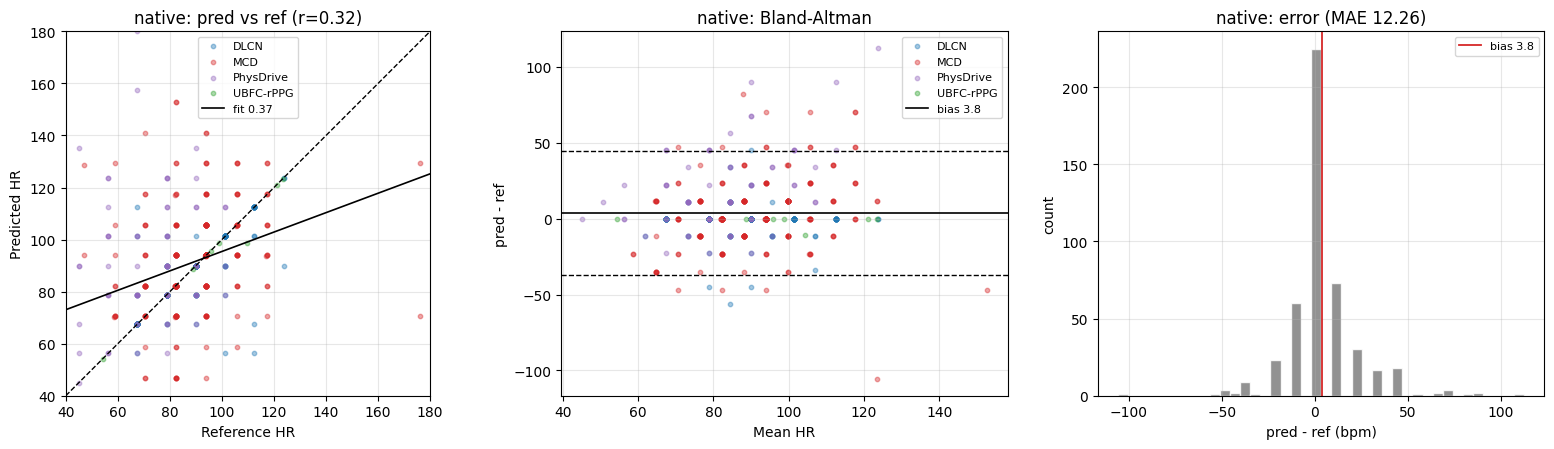

====================================================================== snr | zero-shot: ['PhysDrive']
               n    MAE   RMSE   bias  LoA_low  LoA_high  Pearson_r
DLCN       168.0   2.88   8.46  -0.60   -17.19     15.99       0.82
MCD        232.0   8.56  15.41   0.66   -29.58     30.89       0.49
PhysDrive   68.0  23.33  33.94  21.67   -29.91     73.25      -0.03
UBFC-rPPG    7.0   4.68   7.16  -1.58   -16.36     13.19       0.95
ALL        475.0   8.61  17.52   3.19   -30.61     36.99       0.42


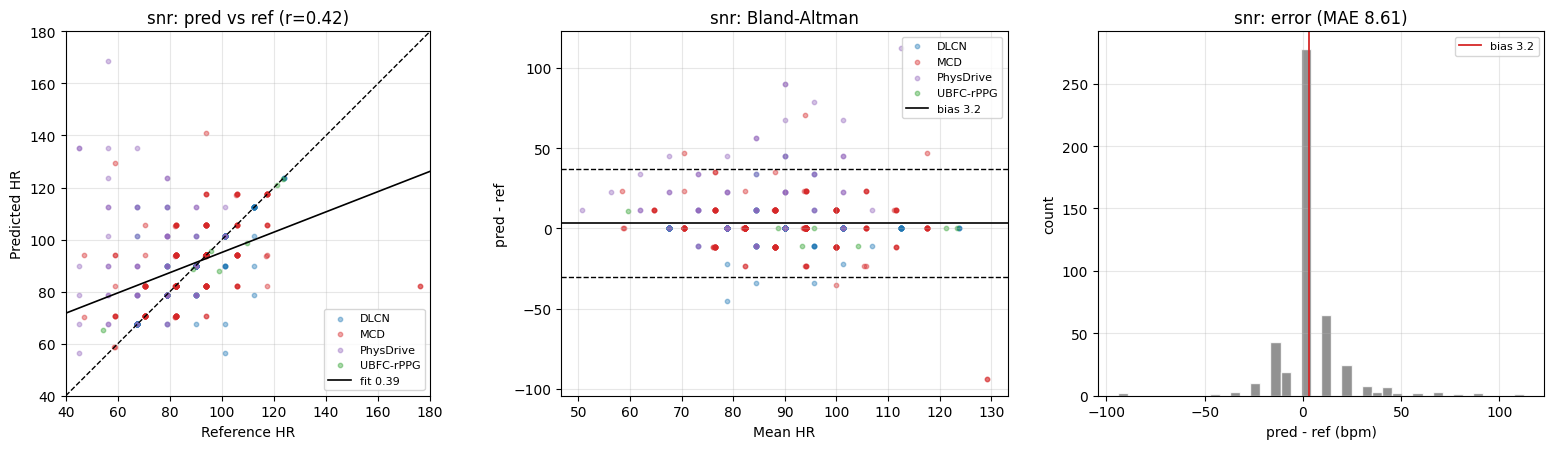

In [9]:
import matplotlib.pyplot as plt

@torch.no_grad()
def collect_predictions(model, loader):
    rows = []
    for batch in loader:
        frames = batch['frames'].to(device, non_blocking=True)
        with autocast('cuda'):
            pred, _ = pn_forward(model, frames)
        pred = pred.float().cpu().numpy()
        hr_true = batch['hr'].numpy(); fps = batch['fps'].numpy(); ds = batch['dataset']
        for i in range(len(pred)):
            if not (40.0 <= hr_true[i] <= 180.0):
                continue
            hp = hr_from_bvp(pred[i], float(fps[i]))
            if np.isfinite(hp):
                rows.append((ds[i], float(hr_true[i]), hp))
    return pd.DataFrame(rows, columns=['dataset', 'hr_true', 'hr_pred'])

def metrics_block(g):
    d = (g['hr_pred'] - g['hr_true']).values
    sd = d.std(ddof=1) if len(d) > 1 else np.nan
    return pd.Series(dict(n=len(g), MAE=np.abs(d).mean(), RMSE=np.sqrt((d ** 2).mean()), bias=d.mean(),
                          LoA_low=d.mean() - 1.96 * sd, LoA_high=d.mean() + 1.96 * sd,
                          Pearson_r=(np.corrcoef(g['hr_true'], g['hr_pred'])[0, 1] if len(g) > 2 else np.nan)))

colors = dict(MCD='tab:red', DLCN='tab:blue')
colors['UBFC-rPPG'] = 'tab:green'; colors['PhysDrive'] = 'tab:purple'
val_loader = make_loader(val_idx, augment=False, clips_per_rec=1)

for cfg in CONFIGS:
    model = build_phasenet().to(device)
    model.load_state_dict(torch.load(results[cfg]['ckpt'], map_location=device)); model.eval()
    pred_df = collect_predictions(model, val_loader)
    summary = pred_df.groupby('dataset').apply(metrics_block, include_groups=False)
    overall = metrics_block(pred_df); overall.name = 'ALL'
    zs = [d for d in summary.index if d not in TRAIN_SET]
    print('=' * 70, cfg, '| zero-shot:', zs)
    print(pd.concat([summary, overall.to_frame().T]).round(2).to_string())

    diff = (pred_df.hr_pred - pred_df.hr_true).values
    bias = diff.mean(); sd = diff.std(ddof=1)
    r = np.corrcoef(pred_df.hr_true, pred_df.hr_pred)[0, 1]
    lim = [40, 180]
    fig, ax = plt.subplots(1, 3, figsize=(16, 4.6))
    for ds, g in pred_df.groupby('dataset'):
        ax[0].scatter(g.hr_true, g.hr_pred, s=10, alpha=0.4, color=colors.get(ds, 'gray'), label=ds)
    ax[0].plot(lim, lim, 'k--', lw=1)
    sl, ic = np.polyfit(pred_df.hr_true, pred_df.hr_pred, 1)
    ax[0].plot(np.array(lim), ic + sl * np.array(lim), 'k-', lw=1.2, label='fit ' + str(round(sl, 2)))
    ax[0].set(xlim=lim, ylim=lim, xlabel='Reference HR', ylabel='Predicted HR', title=cfg + ': pred vs ref (r=' + str(round(r, 2)) + ')', aspect='equal')
    ax[0].legend(fontsize=8); ax[0].grid(alpha=0.3)
    for ds, g in pred_df.groupby('dataset'):
        ax[1].scatter((g.hr_true + g.hr_pred) / 2, g.hr_pred - g.hr_true, s=10, alpha=0.4, color=colors.get(ds, 'gray'), label=ds)
    ax[1].axhline(bias, color='k', lw=1.2, label='bias ' + str(round(bias, 1)))
    ax[1].axhline(bias + 1.96 * sd, color='k', ls='--', lw=1); ax[1].axhline(bias - 1.96 * sd, color='k', ls='--', lw=1)
    ax[1].set(xlabel='Mean HR', ylabel='pred - ref', title=cfg + ': Bland-Altman'); ax[1].legend(fontsize=8); ax[1].grid(alpha=0.3)
    ax[2].hist(diff, bins=40, color='tab:gray', alpha=0.85, edgecolor='white')
    ax[2].axvline(bias, color='tab:red', lw=1.3, label='bias ' + str(round(bias, 1)))
    ax[2].set(xlabel='pred - ref (bpm)', ylabel='count', title=cfg + ': error (MAE ' + str(round(np.abs(diff).mean(), 2)) + ')')
    ax[2].legend(fontsize=8); ax[2].grid(alpha=0.3)
    plt.tight_layout(); plt.show()
    del model; gc.collect(); torch.cuda.empty_cache()

## 10. Discussion and conclusions

PhaseNet was trained twice on the fixed split - with its native loss (neg-Pearson + 0.2 * latent reconstruction) and with the CRVSE SNR recipe (neg-Pearson + SNR, cardiac-SQI weighted) - the reconstruction regulariser held constant so the pulse-supervision term is the only change. The build was clean: the physics-grounded TCN imported and ran with no fragile dependencies and consumed the 72x72 clips directly (3.3 M parameters).

The SNR recipe is a large win for PhaseNet. The native loss converged slowly and left the noisy-reference set uncracked (best shared 10.32, MCD 15.49), whereas the SNR recipe reached shared 6.15 / MCD 8.56 - a 4.18 bpm improvement on the shared metric and a near-halving of MCD. This makes the CRVSE SNR loss beneficial on four of the five architectures tried (PhysNet, PhysFormer, RhythmFormer, PhaseNet); only the Mamba-based RhythmMamba regressed. Frequency-domain supervision plus SQI weighting is the right recipe for this corpus regardless of backbone. The two configs differ in both the SNR term and the SQI weighting, so the gain is the full recipe rather than the SNR term alone.

PhaseNet is not, however, a competitive backbone here. Its best configuration (SNR, 6.15 / 8.56) is worse than the SNR-loss PhysNet (5.22 / 6.84) while carrying four times the parameters (3.3 M vs 0.77 M) and training far slower (~750 s/epoch), and it is well behind RhythmFormer's in-distribution 4.26. Its PhysDrive zero-shot (~23) is moderate and steadier than RhythmFormer's, but that reflects RhythmFormer over-specialising rather than PhaseNet generalising well; the physics grounding delivered a stable, low-dependency model but no accuracy or efficiency advantage.

Conclusion: PhaseNet is retained as a documented, stable negative. It confirms the SNR loss transfers across CNN, transformer and TCN families, but it does not displace PhysNet v2 (the balanced deployable backbone) or RhythmFormer (the in-distribution best), so it is not pursued further.